In [ ]:

%pip install ipympl ipywidgets
%pip install jupyterlab_widgets

ΑΣΚΗΣΕΙΣ ΑΞΙΟΛΟΓΗΣΗΣ 1

ΚΑΡΑΝΑΣΙΟΣ ΑΘΑΝΑΣΙΟΣ ΑΓΓΕΛΟΣ

ΑΕΜ:15919


ΕΡΩΤΗΣΗ 1: Η εξισωση για την περιοδο προκυπτει ως εξης:
$$E=\bar{h}ω=\frac{{n^2}{π^2}\bar{h^2}}{2m{a^2}}=>$$

**$$ω=\frac{{n^2}{π^2}\bar{h}}{2m{a^2}}$$**
Οπου στη συνεχεια με ευκολια προκυπτει:

$$Τ=\frac{4m{a^2}}{{n^2}{π}\bar{h}}$$


In [ ]:
import numpy as np  # Χρειαζόμαστε το pi
n = 1         # Θέλουμε το βασική κατάσταση
a = 1e-10     # Πλάτος πηγαδιού
m = 9.1e-31   # Μάζα ηλεκτρονίων
hbar = 1.0545718e-34    # Η σταθερά του Planck διαιρεμένη με 2pi
T = (4*m*a**2)/(n**2*np.pi*hbar)   # Αλλάξτε αυτή τη γραμμή για να υπολογίσετε την περίοδο, T
print("The period is T =",T, " seconds")


The period is T = 1.0986904691638808e-16  seconds


ΕΡΩΤΗΣΗ 2:Προφανως η συναρτηση που πρεπει να γραφει ειναι η$$\psi_n(x)=\sqrt{\frac{2}{a}}\sin \left( \frac{n\pi}{a}x \right)$$

In [ ]:
spacing = 0.01     # Για μεγαλύτερη ανάλυση, μικρύνετε ακόμη περισσοτερο το νούμερο
x = np.arange(0, 1, spacing)
N = len(x)         # Αριθμός συντεταγμένων

In [ ]:
def psi_n_x(x,n,a=1):
  return np.sqrt(2/a)*np.sin(n*np.pi*x/a)

In [ ]:
def norm(x, psi_n_x):
    return x*np.dot(psi_n_x,np.conjugate(psi_n_x))

ΕΡΩΤΗΣΗ 3

Norm of psi_test =  1.0


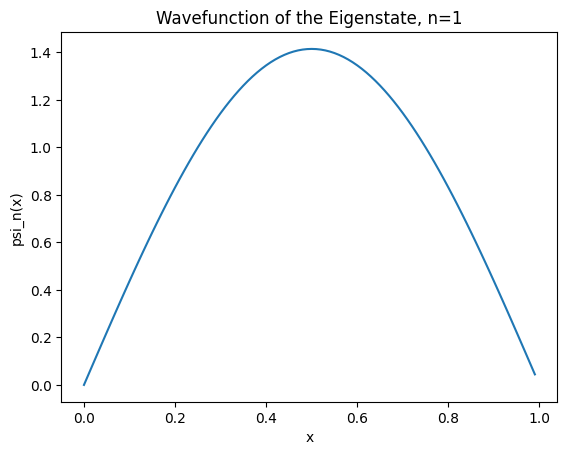

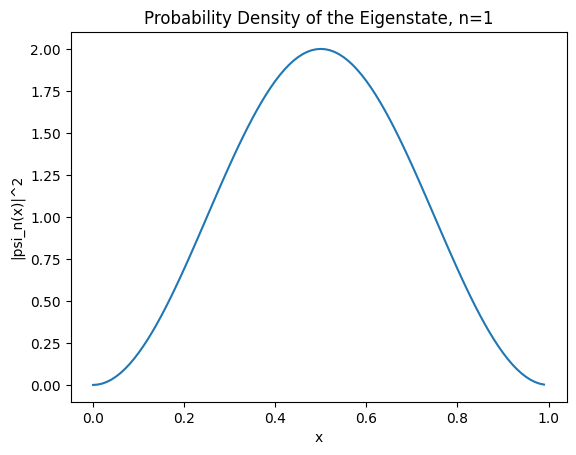

Norm of psi_test =  1.0000000000000002


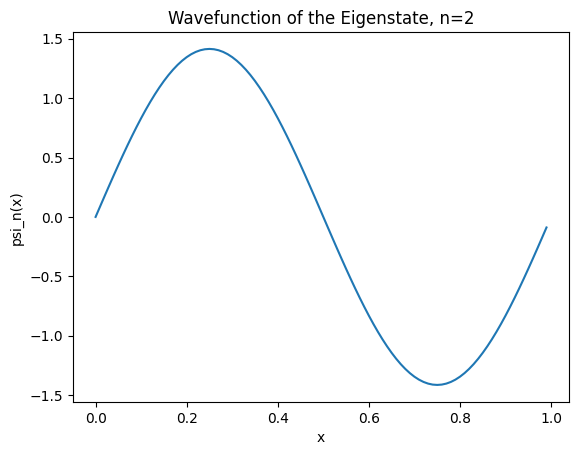

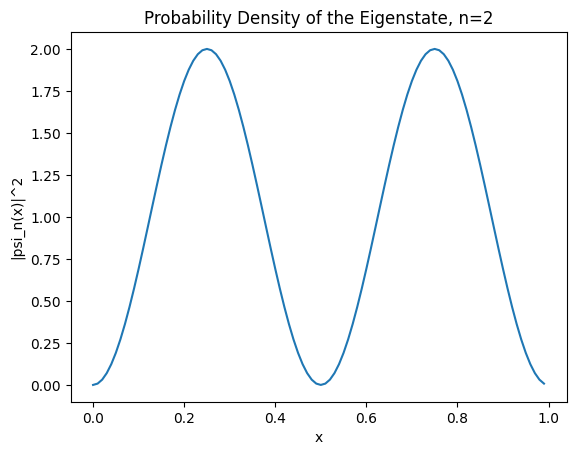

Norm of psi_test =  1.0000000000000002


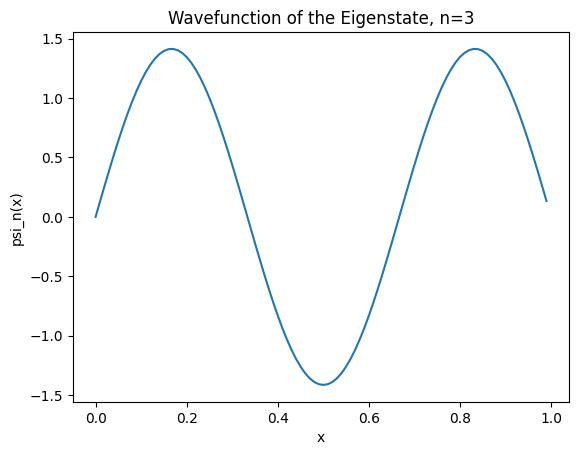

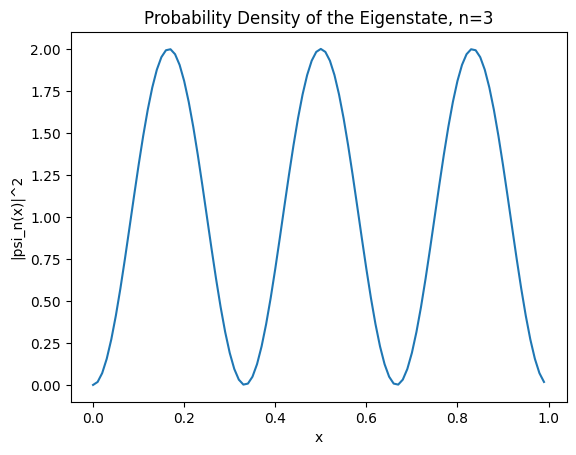

Norm of psi_test =  1.0000000000000002


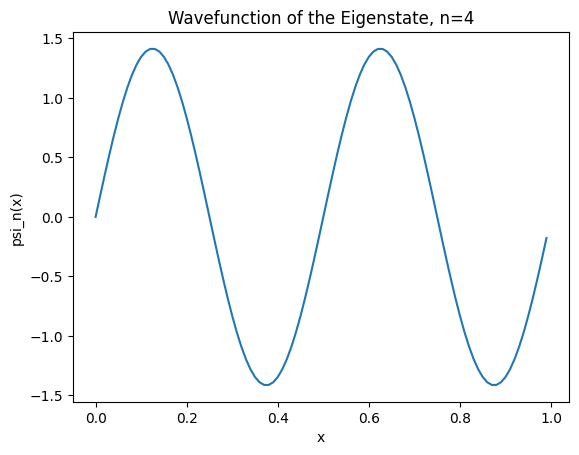

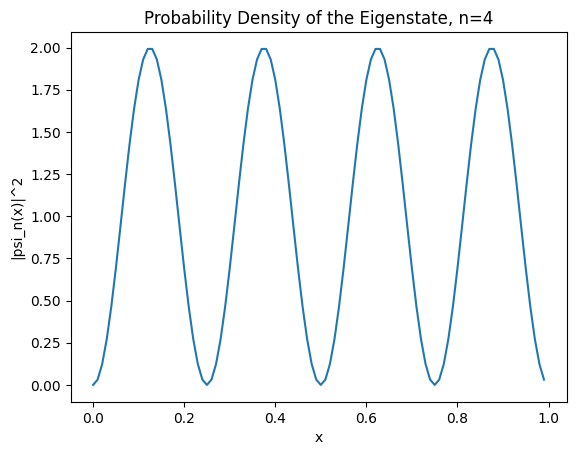

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

n_list=[1,2,3,4]
for n in n_list:
  psi_test = psi_n_x(x,n)
  print("Norm of psi_test = ",norm(spacing, psi_test))

  plt.plot(x, psi_test)
  plt.xlabel("x")
  plt.ylabel("psi_n(x)")
  plt.title("Wavefunction of the Eigenstate, n="+str(n))

  plt.figure()
  plt.plot(x, psi_test*numpy.conjugate(psi_test))
  plt.xlabel("x")
  plt.ylabel("|psi_n(x)|^2")
  plt.title("Probability Density of the Eigenstate, n="+str(n))
  plt.show()

Τα αποτελεσματα της κανονικοποιησης ειναι υπολογισμενα με εξαιρετικη ακριβεια, με τα τελευταια ψηφια κατα πασα πιθανοτητα να εμφανιζονται επειδη η μεθοδος της ολοκληρωσης ειναι αριθμητικη.

Οι κυματοσυναρησεις εμφανιζονται σωστες και αναμενομενες ημιτονοειδεις καμπυλες,αυξανομενης συχνοτητας αναλογης του αριθμου των καταστασεων.



ΕΡΩΤΗΣΗ 4

In [ ]:
def psi_n_x_t(x, n, t):
    return psi_n_x(x,n)*np.exp(-1j*n**2 * np.pi**2 * t /2)

In [ ]:
def wavefunction(x, t, cn):

    # Αρχικά ελέγχουμε ότι οι συντελεστές υπακούουν στον κανόνα ότι η συνολική πιθανότητα = 1
    total_probability = np.dot(np.conjugate(cn),cn)
    if(not abs(total_probability - 1) < 1e-6):
        print("Error! Sum of the conefficients squared does not equal 1! Total Probability =", total_probability)
        return

    # Τώρα δημιουργούμε μια κενή κυματοσυνάρτηση.  Θα προσθέσουμε κάθε ιδιοκατάσταση σε αυτό, σταθμισμένη με τους κατάλληλους συντελεστές.
    wf = np.zeros_like(x)
    for n in range(0,len(cn)):
        wf = wf + cn[n]*psi_n_x_t(x,n,t) # Αυτή είναι η γραμμή που πρέπει να διορθώσετε!

    return wf

In [ ]:
cn=numpy.array([numpy.sqrt(1./2), numpy.sqrt(1./2),0,numpy.sqrt(1./2),0, numpy.sqrt(1./2),0])

AttributeError: 'list' object has no attribute 'set_animated'

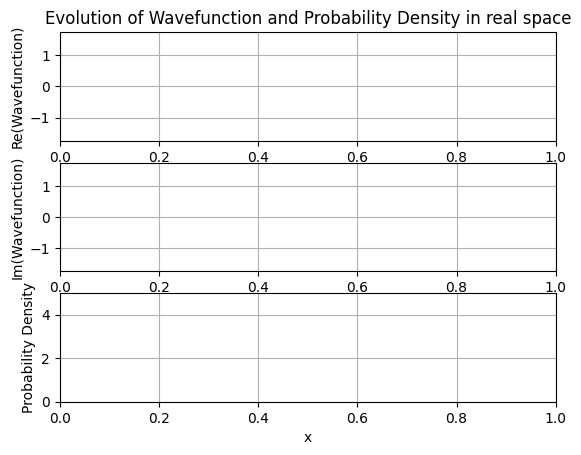

In [ ]:
import matplotlib.animation as animation


# δημιουργήστε ένα σχήμα με τρια subplots
fig, (ax1, ax2, ax3) = plt.subplots(3,1)

# αρχικοποιήστε τρία αντικείμενα γραμμής (ένα σε κάθε άξονα)
line1, = ax1.plot([], [], lw=2)
line2, = ax2.plot([], [], lw=2, color='g')
line3, = ax3.plot([], [], lw=2, color='r')
line = [line1, line2, line3]

# οι ίδιες αρχικοποιήσεις αξόνων με πριν (απλά τώρα το κάνουμε και για τους δύο)
ax1.set_ylim(-1.75, 1.75)
ax1.set_xlim(0, 1)
ax1.grid()
ax1.set_ylabel("Re(Wavefunction)")
ax1.set_title("Evolution of Wavefunction and Probability Density in real space")

ax2.set_ylim(-1.75, 1.75)
ax2.set_xlim(0, 1)
ax2.grid()
ax2.set_ylabel("Im(Wavefunction)")

ax3.set_ylim(0, 5)
ax3.set_xlim(0, 1)
ax3.grid()
ax3.set_xlabel("x")
ax3.set_ylabel("Probability Density")

time_text = ax1.text(0.05, 0.95,'',horizontalalignment='left',verticalalignment='top', transform=ax1.transAxes)
norm_text = ax1.text(0.05, 0.85,'',horizontalalignment='left',verticalalignment='top', transform=ax1.transAxes)
time_per_frame = 0.0001     # Θα μπορούσατε να το αλλάξετε για να κάνετε την κινούμενη εικόνα πιο γρήγορη ή πιο αργή

def run_init():
    line[0].set_data([], [])
    line[1].set_data([], [])
    line[2].set_data([], [])
    return line,

def run(i):
    wf = wavefunction(x, time_per_frame*i, cn)
    y1data = numpy.real(wf)
    y2data = numpy.imag(wf)
    y3data = numpy.conjugate(wf)*wf

    # ενημερώνουμε τα δεδομένα των τριών αντικειμένων γραμμής
    line[0].set_data(x, y1data)
    line[1].set_data(x, y2data)
    line[2].set_data(x, y3data)
    # Εμφάνιση της τρέχουσας χρονικής στιγμής των κινουμένων σχεδίων
    time_text.set_text('tau = %.2f' % (i*time_per_frame))
    norm_text.set_text('norm = %.2f' % (norm(spacing,wf)))
    return line, time_text, norm_text

ani = animation.FuncAnimation(fig, run, init_func=run_init,
                               frames=1000, interval=20, blit=True)

# ani;
plt.show()

Για την ερωτηση 5 δεν μπορεσε να δουλεψει το animation ουτε στο colab αλλα ουτε στο anaconda καθως οι βιβλιοθηκες δεν αποθηκευονταν ο,τι και αν προσπαθησα.